# Taller 1 — Supervisión de contratación pública de bienes (SECOP II, 2019–2025)

**MINE-4101 Ciencia de Datos Aplicada — Universidad de los Andes — 2026-20**

**Integrantes:** _Nombre 1_ · _Nombre 2_

La oficina de control interno necesita decidir, desde el momento de la firma, a qué contratos de compraventa y suministro de bienes hacerles seguimiento cercano. En este notebook exploramos los contratos publicados en SECOP II, definimos qué entendemos por "desviación" frente al plan inicial y buscamos qué características del contrato se asocian con esas desviaciones.

El notebook está organizado en los cuatro puntos del taller:

1. Entendimiento inicial de los datos
2. Estrategia de análisis
3. Desarrollo de la estrategia (procesamiento, pruebas de hipótesis, visualizaciones, modelo)
4. Resultados: criterios de focalización y limitaciones

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multitest import multipletests
from sklearn.metrics import roc_auc_score

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
SEED = 42

In [2]:
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = RAIZ / "data" / "secop_bienes.parquet"
if not DATA.exists():
    import gdown
    DATA.parent.mkdir(parents=True, exist_ok=True)
    gdown.download(id="1R0pSXh2bgCoPKcXlAlafdavVwvzZX6AQ", output=str(DATA), quiet=False)

raw = pd.read_parquet(DATA)
raw.shape

(196391, 36)

## 1. Entendimiento inicial de los datos

### 1.1 Dimensiones y tipos de datos

In [3]:
print(f"Filas: {raw.shape[0]:,}  |  Columnas: {raw.shape[1]}")
print(f"Contratos únicos (id_contrato): {raw['id_contrato'].nunique():,}")
print(f"Rango de fecha de firma: {raw['fecha_de_firma'].min().date()} a {raw['fecha_de_firma'].max().date()}")

Filas: 196,391  |  Columnas: 36
Contratos únicos (id_contrato): 196,391
Rango de fecha de firma: 2019-01-01 a 2025-12-31


In [4]:
def perfil(df):
    out = pd.DataFrame({
        "tipo": df.dtypes.astype(str),
        "nulos_%": df.isna().mean() * 100,
        "no_definido_%": df.apply(lambda s: s.astype(str).str.strip().str.lower().isin(["no definido", "no aplica", "no aplica/no pertenece"]).mean() * 100),
        "valores_unicos": df.apply(lambda s: s.astype(str).nunique()),
    })
    out["ejemplo"] = [str(df[c].dropna().iloc[0])[:45] for c in df.columns]
    return out

perfil(raw)

,tipo,nulos_%,no_definido_%,valores_unicos,ejemplo
id_contrato,str,0.000,0.000,196391,CO1.PCCNTR.1000001
nombre_entidad,str,0.000,0.000,3452,PARQUES NACIONALES NATURALES DE COLOMBIA - DI
departamento,str,0.000,3.824,34,Distrito Capital de Bogotá
ciudad,str,0.000,21.219,676,No Definido
orden,str,0.000,0.005,4,Territorial
sector,str,0.000,12.462,26,Ambiente y Desarrollo Sostenible
rama,str,0.000,0.005,5,Ejecutivo
entidad_centralizada,str,0.000,0.000,2,Centralizada
tipo_de_contrato,str,0.000,0.000,2,Suministros
modalidad_de_contratacion,str,0.000,0.000,9,Mínima cuantía


In [5]:
tipos = {
    "Identificadores / texto libre": ["id_contrato", "nombre_entidad", "objeto_del_contrato", "proveedor_adjudicado", "documento_proveedor", "codigo_de_categoria_principal", "urlproceso"],
    "Categóricas": ["departamento", "ciudad", "orden", "sector", "rama", "entidad_centralizada", "tipo_de_contrato", "modalidad_de_contratacion", "condiciones_de_entrega", "es_pyme", "es_grupo", "g_nero_representante_legal", "nacionalidad_representante_legal", "habilita_pago_adelantado", "el_contrato_puede_ser_prorrogado", "origen_de_los_recursos", "destino_gasto", "estado_contrato", "liquidaci_n", "obligaci_n_ambiental"],
    "Fechas": ["fecha_de_firma", "fecha_de_inicio_del_contrato", "fecha_de_fin_del_contrato"],
    "Numéricas": ["valor_del_contrato", "valor_pagado", "valor_facturado", "valor_pendiente_de_pago", "dias_adicionados"],
    "Texto semiestructurado": ["duraci_n_del_contrato"],
}
pd.DataFrame([(k, len(v), ", ".join(v)) for k, v in tipos.items()], columns=["grupo", "n", "columnas"])

,grupo,n,columnas
0,Identificadores / texto libre,7,"id_contrato, nombre_entidad, objeto_del_contra..."
1,Categóricas,20,"departamento, ciudad, orden, sector, rama, ent..."
2,Fechas,3,"fecha_de_firma, fecha_de_inicio_del_contrato, ..."
3,Numéricas,5,"valor_del_contrato, valor_pagado, valor_factur..."
4,Texto semiestructurado,1,duraci_n_del_contrato


El dataset tiene **196.391 contratos y 36 atributos**, sin duplicados por `id_contrato`. La mayoría de columnas son categóricas (20); hay 5 numéricas (valores monetarios y días adicionados), 3 fechas y varios campos de texto libre o identificadores que no se usan directamente en el análisis. `urlproceso` viene como un diccionario (`{'url': ...}`) y se repite entre contratos porque un mismo proceso puede generar varios contratos (lotes), así que no se trata como duplicado.

Casi no hay nulos "reales" (solo `fecha_de_inicio_del_contrato`, ~1,2 %), pero muchos campos usan etiquetas como *No Definido* o *No aplica* para lo que en la práctica es un faltante. Eso se trata más adelante.

### 1.2 Top 5 de atributos para el análisis

Escogimos los atributos que responden directamente a la pregunta del negocio: dos que **miden la desviación** (lo que queremos anticipar) y tres que **se conocen al momento de la firma** (con lo que se puede focalizar).

| # | Atributo | Rol | Por qué |
|---|---|---|---|
| 1 | `valor_del_contrato` | Característica en la firma | Define la exposición de recursos públicos; se espera que contratos más grandes sean más complejos de ejecutar. |
| 2 | `modalidad_de_contratacion` | Característica en la firma | Refleja el nivel de competencia y control del proceso (mínima cuantía, subasta, licitación, directa, régimen especial). |
| 3 | `destino_gasto` | Característica en la firma | Distingue gasto recurrente (funcionamiento) de proyectos de inversión, que suelen tener más incertidumbre. |
| 4 | `dias_adicionados` | Desviación | Mide directamente la adición de plazo frente al plan inicial. |
| 5 | `valor_pagado` (frente a `valor_del_contrato`) | Desviación | Permite calcular el % de ejecución financiera y detectar presupuesto comprometido que no se ejecutó. |

Otros atributos (`sector`, `orden`, `tipo_de_contrato`, `liquidaci_n`, `estado_contrato`, duración pactada) también se usan en el análisis multivariado, pero estos cinco son el eje.

#### Análisis univariado de los 5 atributos

count                   196,391
mean             65,824,255,028
std          29,015,352,967,837
min                           0
1%                      701,068
5%                    2,309,772
25%                  12,021,214
50%                  33,600,000
75%                 100,000,000
95%                 800,000,000
99%               4,118,481,943
max      12,858,450,316,000,000
Name: valor_del_contrato, dtype: str

Asimetría: 443.2   |   Contratos con valor 0: 188   |   > 1 billón COP: 4


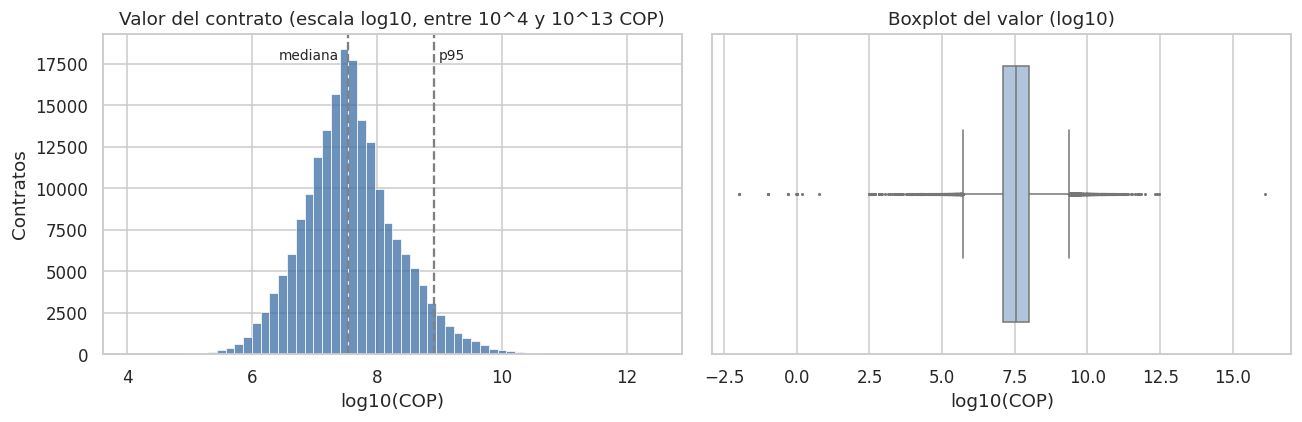

In [6]:
v = raw["valor_del_contrato"]
print(v.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).apply(lambda x: f"{x:,.0f}"))
print(f"\nAsimetría: {v.skew():,.1f}   |   Contratos con valor 0: {(v == 0).sum()}   |   > 1 billón COP: {(v > 1e12).sum()}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(np.log10(v[v.between(1e4, 1e13)]), bins=60, ax=ax[0], color="#3b6ea5")
ax[0].set(title="Valor del contrato (escala log10, entre 10^4 y 10^13 COP)", xlabel="log10(COP)", ylabel="Contratos")
for q, lab, dx in [(v.quantile(.5), "mediana", -1.1), (v.quantile(.95), "p95", .08)]:
    ax[0].axvline(np.log10(q), ls="--", color="gray")
    ax[0].text(np.log10(q) + dx, ax[0].get_ylim()[1] * .92, lab, fontsize=9)
sns.boxplot(x=np.log10(v[v > 0]), ax=ax[1], color="#a9c4e2", fliersize=1)
ax[1].set(title="Boxplot del valor (log10)", xlabel="log10(COP)")
plt.tight_layout()
plt.show()

El valor del contrato tiene una distribución extremadamente sesgada a la derecha: la mediana es de unos **$33,6 millones**, el 75 % de los contratos está por debajo de $100 millones y, sin embargo, la media supera los $65.000 millones por culpa de unos pocos registros. En escala logarítmica la distribución se ve aproximadamente normal, por eso trabajamos el valor en log y con pruebas no paramétricas. Hay 4 contratos por encima de $1 billón (uno de $12.858 billones por tres máquinas) que son claramente errores de digitación.

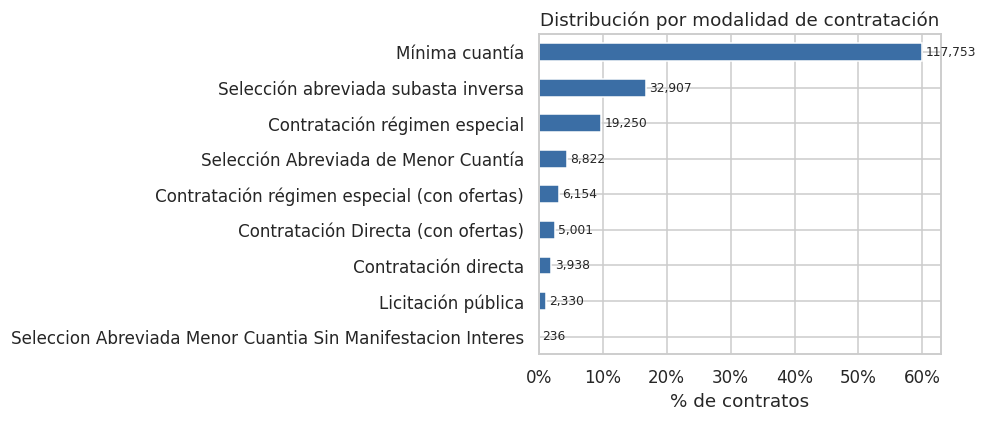

In [7]:
mod_counts = raw["modalidad_de_contratacion"].value_counts()
fig, ax = plt.subplots(figsize=(9, 4))
(mod_counts / len(raw)).sort_values().plot.barh(ax=ax, color="#3b6ea5")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.set(title="Distribución por modalidad de contratación", xlabel="% de contratos", ylabel="")
for i, (n, p) in enumerate(zip(mod_counts.sort_values(), (mod_counts / len(raw)).sort_values())):
    ax.text(p + .005, i, f"{n:,}", va="center", fontsize=8)
plt.tight_layout()
plt.show()

**Modalidad:** hay 9 categorías, pero seis son variantes de tres modalidades (régimen especial con y sin ofertas, contratación directa con y sin ofertas, y dos formas de selección abreviada de menor cuantía). La **mínima cuantía domina con el 60 %** de los contratos, seguida de la subasta inversa (17 %). La licitación pública, que es la modalidad más exigente, solo representa el 1,2 %.

In [8]:
dg = raw["destino_gasto"].value_counts()
print(pd.DataFrame({"contratos": dg, "%": dg / len(raw) * 100}))
valor_dg = raw.groupby("destino_gasto")["valor_del_contrato"].median()
print("\nValor mediano por destino (COP):")
print(valor_dg.apply(lambda x: f"{x:,.0f}"))

                contratos      %
destino_gasto                   
Funcionamiento     117097 59.624
Inversión           78383 39.912
No aplica             532  0.271
No Definido           379  0.193

Valor mediano por destino (COP):
destino_gasto
Funcionamiento    29,480,879
Inversión         39,355,400
No Definido       45,886,400
No aplica          9,505,550
Name: valor_del_contrato, dtype: str


**Destino del gasto:** el 60 % de los contratos es de funcionamiento y el 40 % de inversión. Menos del 0,5 % queda como *No aplica* o *No Definido*. Los contratos de inversión tienen un valor mediano más alto que los de funcionamiento.

count   196,391.000
mean          5.107
std          40.662
min           0.000
50%           0.000
90%           0.000
95%          30.000
99%         122.000
99.9%       316.000
max      14,276.000
Name: dias_adicionados, dtype: float64

% de contratos con días adicionados > 0: 9.5%
Los 5 valores más altos: [730, 731, 770, 874, 14276]


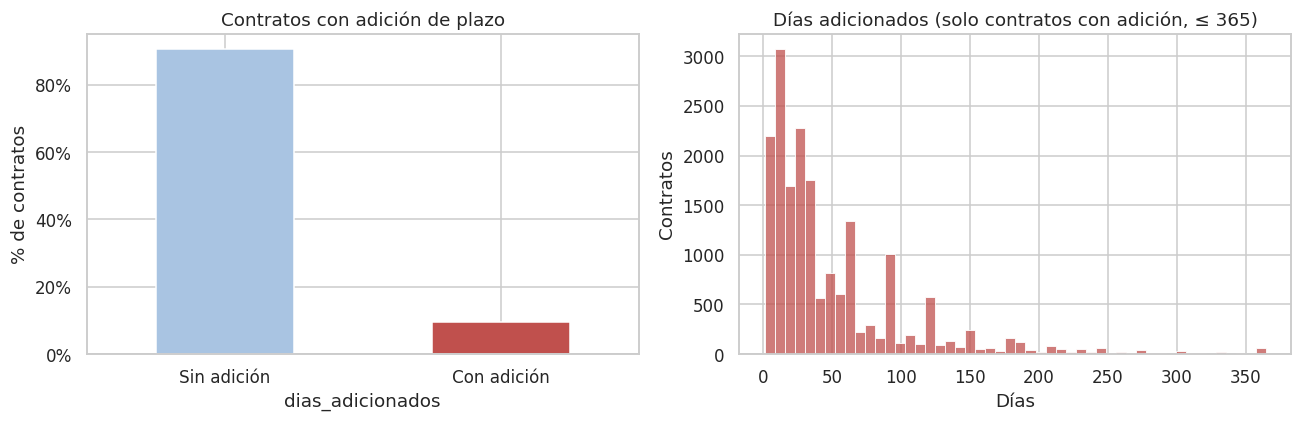

In [9]:
da = raw["dias_adicionados"]
print(da.describe(percentiles=[.5, .9, .95, .99, .999]))
print(f"\n% de contratos con días adicionados > 0: {(da > 0).mean():.1%}")
print("Los 5 valores más altos:", sorted(da.nlargest(5).tolist()))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
(da > 0).value_counts(normalize=True).rename({False: "Sin adición", True: "Con adición"}).plot.bar(ax=ax[0], color=["#a9c4e2", "#c0504d"], rot=0)
ax[0].yaxis.set_major_formatter(mtick.PercentFormatter(1))
ax[0].set(title="Contratos con adición de plazo", ylabel="% de contratos")
sns.histplot(da[(da > 0) & (da <= 365)], bins=50, ax=ax[1], color="#c0504d")
ax[1].set(title="Días adicionados (solo contratos con adición, ≤ 365)", xlabel="Días", ylabel="Contratos")
plt.tight_layout()
plt.show()

**Días adicionados:** el 90 % de los contratos no tiene adiciones de plazo, así que la variable es casi binaria. Entre los que sí tienen, la mayoría suma menos de 60 días, con picos en 30 días (prórrogas de un mes). Hay un valor de 14.276 días (39 años) que no es creíble.

% de contratos con valor_pagado = 0: 54.8%
% con valor_facturado = 0:          46.8%
% con pagado > valor del contrato:   0.09%
% con valor pendiente negativo:      0.07%


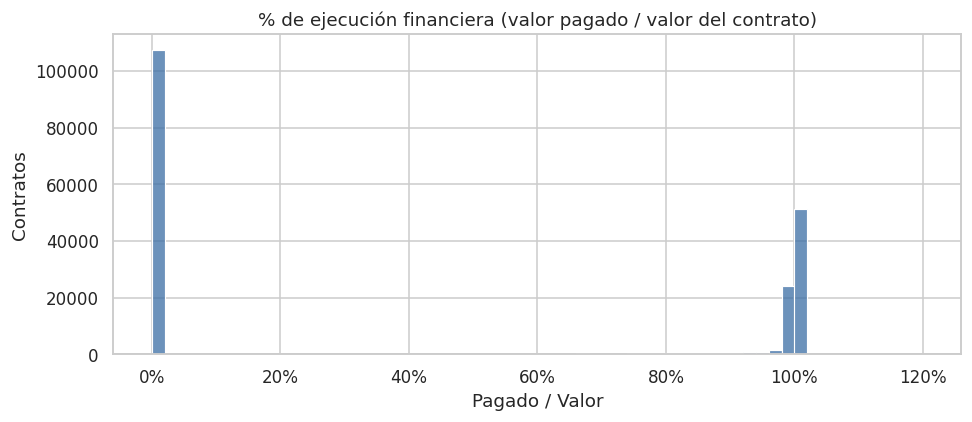

In [10]:
pos = raw["valor_del_contrato"] > 0
ejec = (raw.loc[pos, "valor_pagado"] / raw.loc[pos, "valor_del_contrato"])
print(f"% de contratos con valor_pagado = 0: {(raw['valor_pagado'] == 0).mean():.1%}")
print(f"% con valor_facturado = 0:          {(raw['valor_facturado'] == 0).mean():.1%}")
print(f"% con pagado > valor del contrato:   {(ejec > 1).mean():.2%}")
print(f"% con valor pendiente negativo:      {(raw['valor_pendiente_de_pago'] < 0).mean():.2%}")

fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(ejec.clip(upper=1.2), bins=60, ax=ax, color="#3b6ea5")
ax.set(title="% de ejecución financiera (valor pagado / valor del contrato)", xlabel="Pagado / Valor", ylabel="Contratos")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1))
plt.tight_layout()
plt.show()

**Valor pagado:** la distribución de la ejecución es bimodal: o el contrato aparece pagado casi al 100 % o aparece en 0 %. El **55 % de los contratos tiene `valor_pagado = 0`**, lo cual no es creíble como "no ejecución", porque incluye muchos contratos cerrados. Es un problema conocido de SECOP II: muchas entidades pagan por SIIF u otros sistemas y no registran el pago en la plataforma. Por eso el 0 se interpreta como *sin registro de pago* y no como subejecución (ver 1.3).

### 1.3 Problemas de calidad de datos y tratamiento

In [11]:
anio = raw["fecha_de_firma"].dt.year
calidad_anual = pd.DataFrame({
    "contratos": anio.value_counts().sort_index(),
    "estado_Aprobado_%": raw.groupby(anio)["estado_contrato"].apply(lambda s: (s == "Aprobado").mean() * 100),
    "pagado_0_%": raw.groupby(anio)["valor_pagado"].apply(lambda s: (s == 0).mean() * 100),
    "con_adicion_%": raw.groupby(anio)["dias_adicionados"].apply(lambda s: (s > 0).mean() * 100),
    "fin_despues_jun2025_%": raw.groupby(anio)["fecha_de_fin_del_contrato"].apply(lambda s: (s > "2025-06-30").mean() * 100),
    "en_ejecucion_%": raw.groupby(anio)["estado_contrato"].apply(lambda s: (s == "En ejecución").mean() * 100),
})
calidad_anual

,contratos,estado_Aprobado_%,pagado_0_%,con_adicion_%,fin_despues_jun2025_%,en_ejecucion_%
fecha_de_firma,,,,,,
2019,16425,32.396,72.128,4.177,0.000,0.000
2020,20135,8.552,64.023,7.763,0.065,18.952
2021,24043,1.947,59.132,7.428,0.062,24.889
2022,28070,1.489,52.765,6.694,0.264,25.397
2023,32971,1.295,52.713,7.843,0.740,28.953
2024,34634,1.143,47.142,9.346,3.193,28.637
2025,40113,1.144,50.273,17.286,88.026,37.514


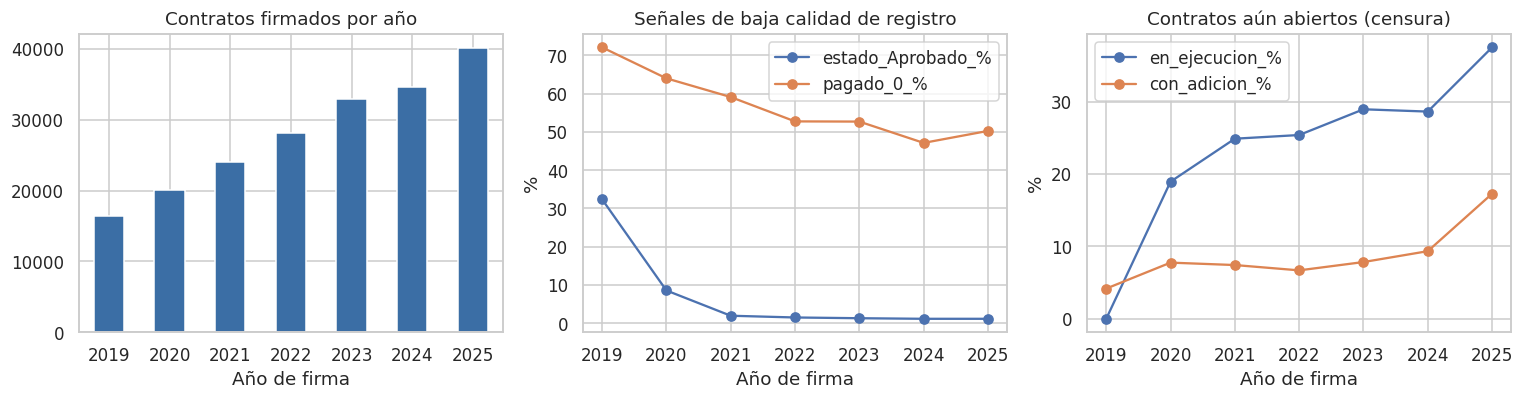

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
calidad_anual["contratos"].plot.bar(ax=axes[0], color="#3b6ea5", rot=0, title="Contratos firmados por año")
calidad_anual[["estado_Aprobado_%", "pagado_0_%"]].plot(ax=axes[1], marker="o", title="Señales de baja calidad de registro")
axes[1].set_ylabel("%")
calidad_anual[["en_ejecucion_%", "con_adicion_%"]].plot(ax=axes[2], marker="o", title="Contratos aún abiertos (censura)")
axes[2].set_ylabel("%")
for a in axes:
    a.set_xlabel("Año de firma")
plt.tight_layout()
plt.show()

**Elección del periodo de análisis: contratos firmados entre 2021 y 2024.**

- **2019 y 2020 se excluyen.** En 2019 el 32 % de los contratos sigue en estado *Aprobado* (nunca se actualizó su ciclo de vida) y el 72 % no tiene pagos registrados; en 2020 esos porcentajes siguen altos. Coincide con la transición de SECOP I a SECOP II, que se volvió obligatorio de forma gradual, y con la contratación de emergencia de 2020 por COVID-19, que no es comparable con años normales.
- **2025 se excluye.** Son contratos recién firmados: una buena parte sigue en ejecución y su desenlace (adiciones, pagos, liquidación) todavía no se observa. Incluirlos subestimaría las desviaciones (censura por la derecha). Se nota en el salto de "en ejecución" en 2025.
- **2021–2024** tiene un registro más estable, suficiente tiempo de observación y cuatro años de volumen alto (~120 mil contratos).

Además, como los valores están en pesos corrientes y entre 2021 y 2024 hubo inflación alta (13,1 % en 2022), los expresamos en **pesos constantes de 2024** usando la variación anual del IPC del DANE.

In [13]:
problemas = pd.DataFrame([
    ["valor_del_contrato", "Valores imposibles (> $1 billón, uno de $12.858 billones) y valores de 0 o menores a $100.000", f"{((raw.valor_del_contrato > 1e12) | (raw.valor_del_contrato < 1e5)).sum():,}", "Se excluyen. No hay forma de recuperar el valor real y distorsionan cualquier promedio."],
    ["valor_pagado / valor_facturado", "55 % de pagos en 0, incluidos contratos cerrados (subregistro de pagos en SECOP II)", f"{(raw.valor_pagado == 0).sum():,}", "El 0 se trata como 'sin registro'. La subejecución solo se mide en contratos terminados que sí registran facturación."],
    ["valor_pagado", "Pagado mayor al valor del contrato (adiciones en valor no reflejadas)", f"{(raw.valor_pagado > raw.valor_del_contrato).sum():,}", "El % de ejecución se trunca en 100 %."],
    ["valor_pendiente_de_pago", "Valores negativos", f"{(raw.valor_pendiente_de_pago < 0).sum():,}", "No se usa; se recalcula la ejecución con pagado/valor."],
    ["dias_adicionados", "Valor atípico imposible (14.276 días)", f"{(raw.dias_adicionados > 1095).sum():,}", "Se marca como faltante (> 3 años adicionados)."],
    ["fecha_de_fin_del_contrato", "Fechas imposibles (año 202, 2065) y fin anterior a la firma; además, la fecha de fin ya incluye las prórrogas", f"{((raw.fecha_de_fin_del_contrato < raw.fecha_de_firma) | (raw.fecha_de_fin_del_contrato.dt.year > 2035)).sum():,}", "No se usa para la duración pactada; en su lugar se procesa el campo de texto duraci_n_del_contrato."],
    ["duraci_n_del_contrato", "Texto con unidades mixtas (días, meses, años, semanas, horas) y registros sin número ('Dia(s)', 'No definido')", f"{raw.duraci_n_del_contrato.isin(['Dia(s)', 'Mes(es)', 'No definido']).sum():,}", "Se convierte a días; los registros sin número quedan como faltantes."],
    ["fecha_de_inicio_del_contrato", "Nulos", f"{raw.fecha_de_inicio_del_contrato.isna().sum():,}", "No se usa directamente (la fecha de firma sí está completa)."],
    ["sector / estado_contrato", "Mayúsculas inconsistentes ('defensa', 'terminado', 'cedido')", "—", "Se normaliza el texto."],
    ["sector / orden / destino / departamento", "Etiquetas 'No Definido', 'No aplica/No pertenece'", f"{(raw.sector == 'No aplica/No pertenece').sum():,} en sector", "Se mantienen como categoría propia (en sector son casi todas entidades territoriales); se excluyen solo en el modelo cuando son muy pocas."],
    ["modalidad_de_contratacion", "Nueve etiquetas que corresponden a seis modalidades", "—", "Se agrupan en: Mínima cuantía, Subasta inversa, Menor cuantía, Régimen especial, Directa y Licitación pública."],
    ["fecha_de_firma", "Siete años con calidad de registro distinta y contratos 2025 sin desenlace", "—", "Se restringe a 2021–2024 (ver arriba)."],
], columns=["atributo", "problema", "registros afectados", "tratamiento"])
problemas.style.hide(axis="index").set_properties(**{"text-align": "left", "white-space": "pre-wrap"})

atributo,problema,registros afectados,tratamiento
valor_del_contrato,"Valores imposibles (> $1 billón, uno de $12.858 billones) y valores de 0 o menores a $100.000",405,Se excluyen. No hay forma de recuperar el valor real y distorsionan cualquier promedio.
valor_pagado / valor_facturado,"55 % de pagos en 0, incluidos contratos cerrados (subregistro de pagos en SECOP II)","107,639",El 0 se trata como 'sin registro'. La subejecución solo se mide en contratos terminados que sí registran facturación.
valor_pagado,Pagado mayor al valor del contrato (adiciones en valor no reflejadas),177,El % de ejecución se trunca en 100 %.
valor_pendiente_de_pago,Valores negativos,144,No se usa; se recalcula la ejecución con pagado/valor.
dias_adicionados,Valor atípico imposible (14.276 días),1,Se marca como faltante (> 3 años adicionados).
fecha_de_fin_del_contrato,"Fechas imposibles (año 202, 2065) y fin anterior a la firma; además, la fecha de fin ya incluye las prórrogas","2,608",No se usa para la duración pactada; en su lugar se procesa el campo de texto duraci_n_del_contrato.
duraci_n_del_contrato,"Texto con unidades mixtas (días, meses, años, semanas, horas) y registros sin número ('Dia(s)', 'No definido')","20,819",Se convierte a días; los registros sin número quedan como faltantes.
fecha_de_inicio_del_contrato,Nulos,"2,440",No se usa directamente (la fecha de firma sí está completa).
sector / estado_contrato,"Mayúsculas inconsistentes ('defensa', 'terminado', 'cedido')",—,Se normaliza el texto.
sector / orden / destino / departamento,"Etiquetas 'No Definido', 'No aplica/No pertenece'","24,465 en sector",Se mantienen como categoría propia (en sector son casi todas entidades territoriales); se excluyen solo en el modelo cuando son muy pocas.


### 1.4 Limpieza y construcción del dataset de análisis

In [14]:
MODALIDAD = {
    "Mínima cuantía": "Mínima cuantía",
    "Selección abreviada subasta inversa": "Subasta inversa",
    "Selección Abreviada de Menor Cuantía": "Menor cuantía",
    "Seleccion Abreviada Menor Cuantia Sin Manifestacion Interes": "Menor cuantía",
    "Contratación régimen especial": "Régimen especial",
    "Contratación régimen especial (con ofertas)": "Régimen especial",
    "Contratación directa": "Directa",
    "Contratación Directa (con ofertas)": "Directa",
    "Licitación pública": "Licitación pública",
}
ORDEN_MOD = ["Mínima cuantía", "Subasta inversa", "Menor cuantía", "Régimen especial", "Directa", "Licitación pública"]

IPC_ANUAL = {2022: 0.1312, 2023: 0.0928, 2024: 0.0520}
FACTOR_2024 = {2024: 1.0}
for a in [2023, 2022, 2021]:
    FACTOR_2024[a] = FACTOR_2024[a + 1] * (1 + IPC_ANUAL[a + 1])

UNIDAD_DIAS = {"Dia": 1, "Semana": 7, "Mes": 30.4, "Año": 365, "Hora": 1 / 24}


def duracion_pactada(s):
    partes = s.str.extract(r"(\d+)\s*(Dia|Semana|Mes|Año|Hora)")
    return partes[0].astype(float) * partes[1].map(UNIDAD_DIAS)


def limpiar(df):
    df = df.drop(columns=["urlproceso"]).copy()
    for c in ["sector", "estado_contrato"]:
        df[c] = df[c].str.strip().str.capitalize()
    df["anio"] = df["fecha_de_firma"].dt.year
    df["modalidad"] = pd.Categorical(df["modalidad_de_contratacion"].map(MODALIDAD), categories=ORDEN_MOD)
    df["dias_adicionados"] = df["dias_adicionados"].where(df["dias_adicionados"] <= 1095)
    dur = duracion_pactada(df["duraci_n_del_contrato"])
    df["duracion_pactada"] = dur.where(dur.between(1, 3650))
    df = df[df["valor_del_contrato"].between(1e5, 1e12)]
    df = df[df["anio"].between(2021, 2024)].copy()
    df["valor_real"] = df["valor_del_contrato"] * df["anio"].map(FACTOR_2024)
    df["log_valor"] = np.log10(df["valor_real"])
    return df


d = limpiar(raw)
print(f"Contratos en el dataset de análisis: {len(d):,} ({len(d) / len(raw):.1%} del original)")
print(f"Duración pactada sin dato o fuera de rango (0 o > 10 años): {d['duracion_pactada'].isna().mean():.1%}")
d[["valor_real", "duracion_pactada", "dias_adicionados"]].describe().T

Contratos en el dataset de análisis: 119,505 (60.9% del original)
Duración pactada sin dato o fuera de rango (0 o > 10 años): 0.1%


,count,mean,std,min,25%,50%,75%,max
valor_real,"119,505.000","339,414,042.638","4,577,240,339.358","101,150.000","14,113,000.000","35,825,049.960","111,953,764.000","709,608,015,921.352"
duracion_pactada,"119,360.000",97.740,117.764,1.000,25.000,60.000,148.000,"3,648.000"
dias_adicionados,"119,505.000",3.792,20.922,0.000,0.000,0.000,0.000,874.000


Después de la limpieza quedan **119.505 contratos firmados entre 2021 y 2024** (61 % del total). La mayor parte de lo que se descarta corresponde a los años excluidos; los registros eliminados por valores imposibles son apenas 405. La duración pactada queda con una mediana de 60 días y solo un 0,1 % sin dato.

## 2. Estrategia de análisis

Primero convertimos la pregunta del negocio en variables medibles. Un contrato "se desvía del plan" si presenta alguno de tres eventos: **(i) adición de plazo** (`dias_adicionados > 0`), **(ii) subejecución**, es decir, un contrato ya terminado o cerrado que registra facturación pero pagó menos del 90 % de lo comprometido, y **(iii) cierre sin liquidar** (terminado o cerrado con `liquidaci_n = No`). La subejecución y la liquidación solo se calculan sobre contratos terminados o cerrados, porque en uno en ejecución todavía no se puede saber si se va a ejecutar o liquidar. Por el subregistro de pagos, la subejecución solo se evalúa en contratos con facturación registrada, y la liquidación se analiza aparte porque su obligatoriedad depende del tipo de contrato y del manual de cada entidad. Como variable principal usamos un indicador combinado de **desviación = adición de plazo o subejecución**, y dejamos la liquidación como un tercer frente de revisión.

Luego seguimos un embudo de lo simple a lo multivariado: (1) estadísticos descriptivos y tasas de desviación por cada característica conocida en la firma (valor, modalidad, destino del gasto, sector, orden, tipo de contrato, duración pactada); (2) **pruebas de hipótesis explícitas**: chi-cuadrado con V de Cramér para asociaciones entre categóricas, pruebas z de dos proporciones con h de Cohen para comparar grupos, Mann-Whitney con correlación biserial de rangos para el valor (por su asimetría) y Spearman para la duración. Con ~120 mil registros casi cualquier diferencia sale significativa, así que reportamos siempre el **tamaño del efecto** y corregimos por comparaciones múltiples (Holm); (3) visualizaciones que cruzan varios atributos (mapas de calor valor × modalidad, tasas por sector y destino); (4) una **regresión logística** que estima el efecto de cada atributo controlando por los demás, para separar lo que es efecto propio de lo que es confusión (por ejemplo, la modalidad está muy ligada al valor), y (5) una validación temporal (entrenar con 2021–2023 y probar en 2024) para medir qué tanto de las desviaciones se capturaría revisando solo una fracción de los contratos. De ahí salen los criterios de focalización.

## 3. Desarrollo de la estrategia

### 3.1 Variables de desviación

In [15]:
d["finalizado"] = d["estado_contrato"].isin(["Cerrado", "Terminado"])
d["con_facturacion"] = d["valor_facturado"] > 0
d["ejecucion"] = (d["valor_pagado"] / d["valor_del_contrato"]).clip(upper=1)

d["adicion"] = (d["dias_adicionados"] > 0).astype(float).where(d["dias_adicionados"].notna())
d["subejecucion"] = (d["ejecucion"] < 0.9).astype(float).where(d["finalizado"] & d["con_facturacion"])
d["sin_liquidar"] = (d["liquidaci_n"] == "No").astype(float).where(d["finalizado"])
d["desviacion"] = np.where(
    d["subejecucion"].notna(),
    ((d["adicion"] == 1) | (d["subejecucion"] == 1)).astype(float),
    d["adicion"],
)

resumen = pd.DataFrame({
    "base (n)": [d["adicion"].notna().sum(), d["subejecucion"].notna().sum(), d["sin_liquidar"].notna().sum(), d["desviacion"].notna().sum()],
    "tasa": [d["adicion"].mean(), d["subejecucion"].mean(), d["sin_liquidar"].mean(), d["desviacion"].mean()],
}, index=["Adición de plazo", "Subejecución (<90 % pagado)", "Cerrado sin liquidar", "Desviación (adición o subejecución)"])
resumen

,base (n),tasa
Adición de plazo,119505,0.079
Subejecución (<90 % pagado),41737,0.130
Cerrado sin liquidar,66294,0.565
Desviación (adición o subejecución),119505,0.124


Contratos finalizados: 55.5%
Finalizados sin ningún registro de facturación: 37.0%


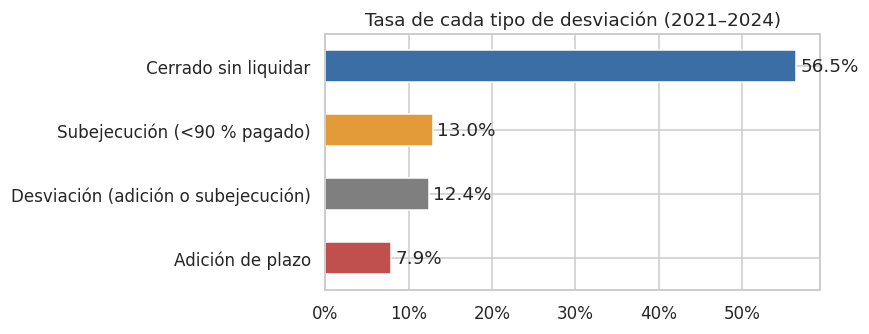

In [16]:
print(f"Contratos finalizados: {d['finalizado'].mean():.1%}")
print(f"Finalizados sin ningún registro de facturación: {(~d.loc[d['finalizado'], 'con_facturacion']).mean():.1%}")
fig, ax = plt.subplots(figsize=(8, 3.2))
colores = {"Adición de plazo": "#c0504d", "Subejecución (<90 % pagado)": "#e39b3a", "Cerrado sin liquidar": "#3b6ea5", "Desviación (adición o subejecución)": "#7f7f7f"}
orden_tasas = resumen["tasa"].sort_values()
orden_tasas.plot.barh(ax=ax, color=[colores[i] for i in orden_tasas.index])
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1))
for i, t in enumerate(resumen["tasa"].sort_values()):
    ax.text(t + .005, i, f"{t:.1%}", va="center")
ax.set(title="Tasa de cada tipo de desviación (2021–2024)", xlabel="")
plt.tight_layout()
plt.show()

- El **7,9 %** de los contratos tuvo adición de plazo.
- De los contratos terminados que registran facturación, el **13 %** pagó menos del 90 % de lo comprometido.
- El **56,5 %** de los contratos terminados o cerrados figura sin liquidar. Es una cifra tan alta que más que una "desviación" parece una práctica generalizada (o un problema de registro), así que la analizamos por separado y no la mezclamos en el indicador principal.
- El **37 %** de los contratos finalizados no tiene ninguna facturación registrada en SECOP II. Esto es en sí mismo un hallazgo para control interno: en más de un tercio de los contratos cerrados no hay trazabilidad del pago en la plataforma.
- Combinando adición y subejecución, el **12,4 %** de los contratos presenta alguna desviación.

### 3.2 Análisis bivariado: ¿qué características se asocian con las desviaciones?

In [17]:
def tasas(col, data=d, orden=None):
    t = data.groupby(col, observed=True).agg(
        contratos=("id_contrato", "size"),
        adicion=("adicion", "mean"),
        subejecucion=("subejecucion", "mean"),
        sin_liquidar=("sin_liquidar", "mean"),
        desviacion=("desviacion", "mean"),
        valor_mediano_M=("valor_real", lambda x: x.median() / 1e6),
    )
    return t.reindex(orden) if orden is not None else t


tasas("modalidad", orden=ORDEN_MOD)

,contratos,adicion,subejecucion,sin_liquidar,desviacion,valor_mediano_M
modalidad,,,,,,
Mínima cuantía,70115,0.061,0.115,0.568,0.104,24.310
Subasta inversa,20129,0.125,0.144,0.465,0.181,232.051
Menor cuantía,5410,0.128,0.154,0.479,0.181,214.535
Régimen especial,17073,0.074,0.190,0.734,0.111,32.674
Directa,5236,0.069,0.120,0.547,0.108,82.997
Licitación pública,1542,0.254,0.187,0.465,0.315,"1,469.805"


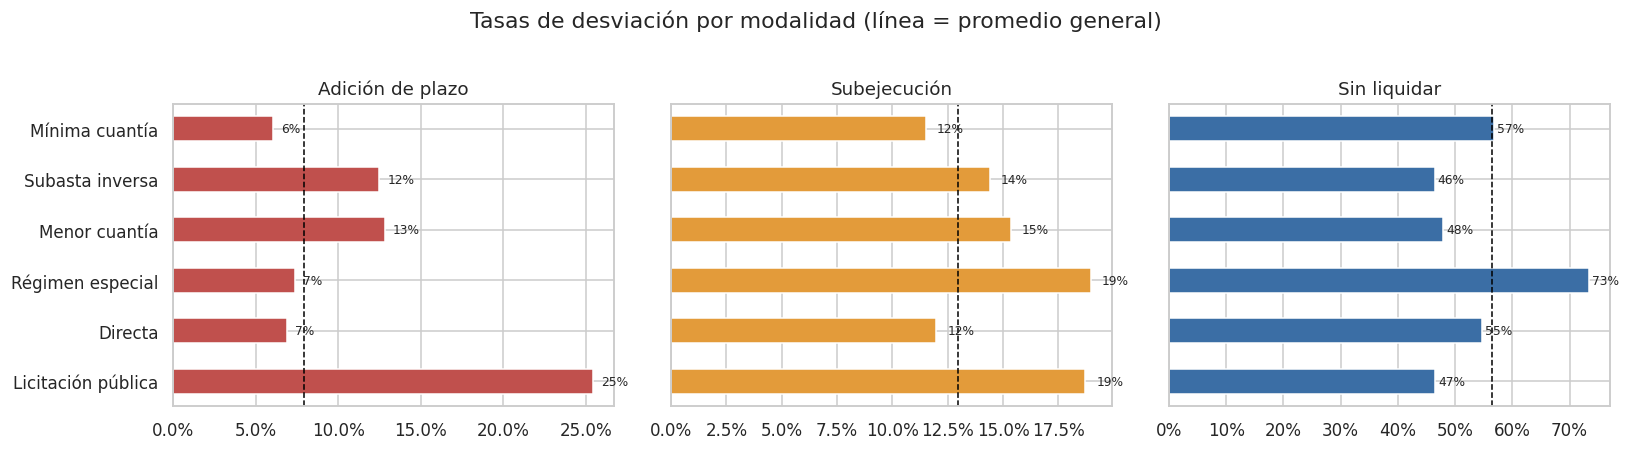

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
t = tasas("modalidad", orden=ORDEN_MOD)
for ax, col, color in zip(axes, ["adicion", "subejecucion", "sin_liquidar"], ["#c0504d", "#e39b3a", "#3b6ea5"]):
    t[col].plot.barh(ax=ax, color=color)
    ax.axvline(d[col].mean(), ls="--", color="black", lw=1)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1))
    ax.set(title={"adicion": "Adición de plazo", "subejecucion": "Subejecución", "sin_liquidar": "Sin liquidar"}[col], ylabel="")
    for i, val in enumerate(t[col]):
        ax.text(val + .005, i, f"{val:.0%}", va="center", fontsize=8)
axes[0].invert_yaxis()
fig.suptitle("Tasas de desviación por modalidad (línea = promedio general)", y=1.02)
plt.tight_layout()
plt.show()

La **licitación pública** es la modalidad con más desviaciones: uno de cada cuatro contratos tuvo adición de plazo (25 %), frente al 6 % de la mínima cuantía. Subasta inversa y menor cuantía están en un nivel intermedio (~13 %). El **régimen especial** sobresale en otra dimensión: es donde más contratos quedan sin liquidar (73 %) y también tiene la subejecución más alta (19 %).

Sin embargo, la tabla también muestra que las modalidades tienen tamaños muy distintos: el valor mediano de una licitación es de ~$1.470 millones contra ~$24 millones en mínima cuantía. Hay que verificar si el efecto es de la modalidad o simplemente del tamaño del contrato.

In [19]:
d["quintil_valor"] = pd.qcut(d["valor_real"], 5, labels=["Q1 (menor)", "Q2", "Q3", "Q4", "Q5 (mayor)"])
cortes = d["valor_real"].quantile([.2, .4, .6, .8]).div(1e6).round(1)
print("Cortes de los quintiles (millones COP 2024):", cortes.tolist())
tasas("quintil_valor")

Cortes de los quintiles (millones COP 2024): [10.7, 26.7, 53.0, 155.3]


,contratos,adicion,subejecucion,sin_liquidar,desviacion,valor_mediano_M
quintil_valor,,,,,,
Q1 (menor),23901,0.027,0.094,0.653,0.058,5.260
Q2,23901,0.054,0.116,0.596,0.095,17.939
Q3,23905,0.067,0.126,0.566,0.112,35.827
Q4,23897,0.096,0.138,0.528,0.145,86.357
Q5 (mayor),23901,0.152,0.172,0.487,0.211,404.652


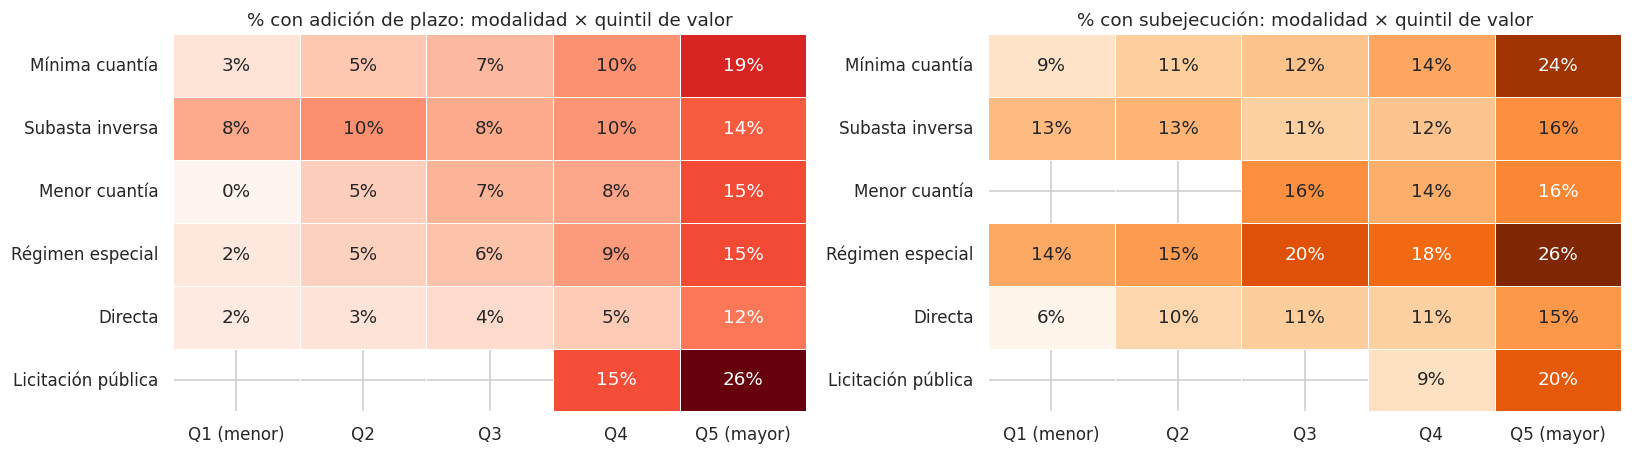

In [20]:
heat = d.pivot_table(index="modalidad", columns="quintil_valor", values="adicion", aggfunc="mean", observed=False)
n_heat = d.pivot_table(index="modalidad", columns="quintil_valor", values="adicion", aggfunc="size", observed=False)
heat = heat.where(n_heat >= 30)

fig, ax = plt.subplots(1, 2, figsize=(15, 4.3))
sns.heatmap(heat, annot=True, fmt=".0%", cmap="Reds", ax=ax[0], cbar=False, linewidths=.5)
ax[0].set(title="% con adición de plazo: modalidad × quintil de valor", xlabel="", ylabel="")
heat2 = d.pivot_table(index="modalidad", columns="quintil_valor", values="subejecucion", aggfunc="mean", observed=False)
n2 = d.pivot_table(index="modalidad", columns="quintil_valor", values="subejecucion", aggfunc="count", observed=False)
sns.heatmap(heat2.where(n2 >= 30), annot=True, fmt=".0%", cmap="Oranges", ax=ax[1], cbar=False, linewidths=.5)
ax[1].set(title="% con subejecución: modalidad × quintil de valor", xlabel="", ylabel="")
plt.tight_layout()
plt.show()

El valor tiene una relación clara y monótona con la desviación: la adición de plazo pasa del **2,7 % en el quintil más bajo al 15,2 % en el más alto** (5,6 veces más), y la subejecución de 9 % a 17 %. En el mapa de calor se ve que, **dentro de un mismo rango de valor**, las diferencias entre modalidades se reducen bastante: una buena parte de lo que parecía "efecto licitación" es en realidad "efecto contrato grande". La excepción es la contratación directa, que tiene menos adiciones que las demás en casi todos los rangos de valor.

La tasa de contratos sin liquidar va en sentido contrario: baja a medida que sube el valor (65 % en Q1 contra 49 % en Q5). Tiene sentido: los contratos pequeños de ejecución instantánea muchas veces no se liquidan.

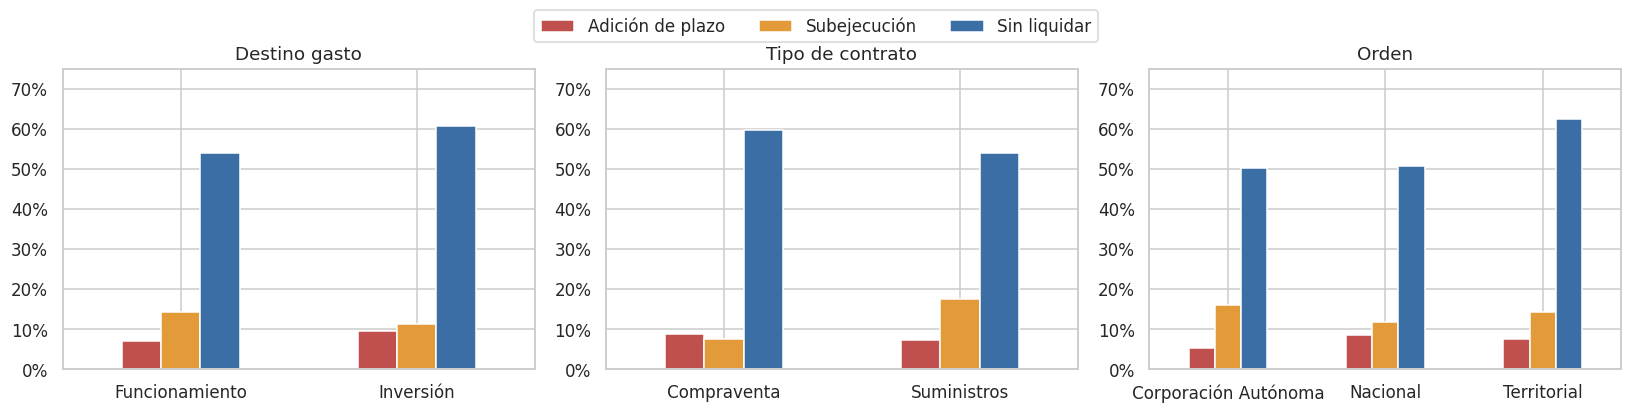

contratos  adicion  subejecucion  sin_liquidar  desviacion  valor_mediano_M
destino_gasto    Funcionamiento            71077    0.069         0.144         0.538       0.114           32.190
                 Inversión                 48299    0.094         0.113         0.606       0.139           42.000
                 No Definido                 126    0.063         0.197         0.415       0.159           59.912
                 No aplica                     3    0.000           NaN           NaN       0.000            0.803
tipo_de_contrato Compraventa               53591    0.087         0.075         0.597       0.113           32.776
                 Suministros               65914    0.073         0.175         0.540       0.133           37.552
orden            Corporación Autónoma       1406    0.051         0.161         0.503       0.115           35.729
                 Nacional                  54899    0.086         0.118         0.508       0.133           40.800
                 No Definido                   9    0.000           NaN           NaN       0.000            2.775
                 Territorial               63191    0.074         0.142         0.624       0.117           33.679

In [21]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
for a, col in zip(ax, ["destino_gasto", "tipo_de_contrato", "orden"]):
    t = tasas(col)
    t = t[t["contratos"] > 500][["adicion", "subejecucion", "sin_liquidar"]]
    t.plot.bar(ax=a, rot=0, color=["#c0504d", "#e39b3a", "#3b6ea5"], legend=False)
    a.yaxis.set_major_formatter(mtick.PercentFormatter(1))
    a.set(title=col.replace("_", " ").capitalize(), xlabel="", ylim=(0, .75))
fig.legend(["Adición de plazo", "Subejecución", "Sin liquidar"], loc="upper center", ncol=3, bbox_to_anchor=(.5, 1.06))
plt.tight_layout()
plt.show()
pd.concat({c: tasas(c) for c in ["destino_gasto", "tipo_de_contrato", "orden"]})

- **Destino del gasto:** la inversión tiene más adiciones (9,4 % vs 6,9 %) y más contratos sin liquidar (61 % vs 54 %), pero menos subejecución que el funcionamiento.
- **Tipo de contrato:** es la diferencia más marcada en subejecución: los **suministros** subejecutan el 17,5 % de las veces contra 7,5 % de las compraventas. Es consistente con la figura de "monto agotable": se compromete un tope y se va pidiendo según la necesidad, así que es normal que no se consuma todo. Esto no es necesariamente una mala práctica, pero sí indica una sobrestimación del presupuesto que inmoviliza recursos.
- **Orden:** las entidades territoriales dejan más contratos sin liquidar (62 % vs 51 %); en adición de plazo la diferencia con las nacionales es pequeña.

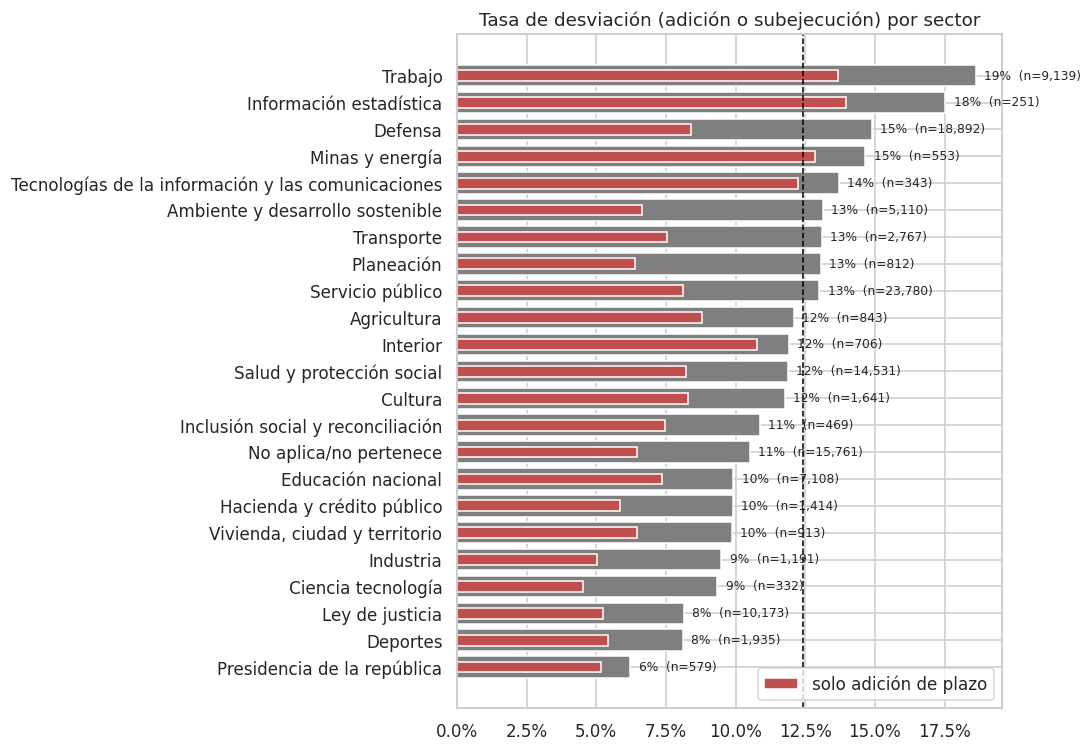

In [22]:
sec = tasas("sector")
sec = sec[sec["contratos"] >= 200].sort_values("desviacion")
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(sec.index, sec["desviacion"], color="#7f7f7f")
ax.barh(sec.index, sec["adicion"], color="#c0504d", height=.4, label="solo adición de plazo")
ax.axvline(d["desviacion"].mean(), ls="--", color="black", lw=1)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1))
for i, (tv, n) in enumerate(zip(sec["desviacion"], sec["contratos"])):
    ax.text(tv + .003, i, f"{tv:.0%}  (n={n:,})", va="center", fontsize=8)
ax.set(title="Tasa de desviación (adición o subejecución) por sector", xlabel="")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

Entre sectores con al menos 200 contratos, la tasa de desviación va de ~6 % a ~19 % (promedio 12,4 %). El más alto es **Trabajo** (18,6 %, con más de 9 mil contratos; ahí está el SENA, con muchas compras de materiales de formación), seguido de **Información estadística**, **Defensa** (15 %, que por su volumen es donde más desviaciones hay en términos absolutos), **Minas y energía** y **TIC**. En Trabajo predomina la adición de plazo, mientras que en Defensa, Ambiente y Transporte predomina la subejecución. Varios de los sectores pequeños tienen tasas menos estables por su bajo número de contratos.

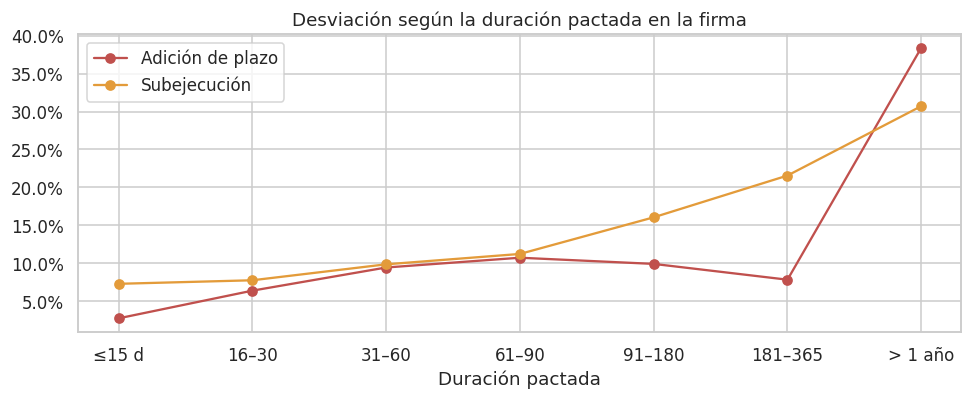

,contratos,adicion,subejecucion,sin_liquidar,desviacion,valor_mediano_M
duracion_rango,,,,,,
≤15 d,24070,0.027,0.073,0.635,0.050,21.848
16–30,16080,0.064,0.078,0.620,0.090,26.534
31–60,20774,0.094,0.099,0.612,0.128,35.195
61–90,13371,0.107,0.112,0.570,0.147,48.840
91–180,20928,0.099,0.161,0.499,0.158,61.644
181–365,22765,0.078,0.216,0.491,0.159,54.600
> 1 año,1372,0.384,0.307,0.380,0.449,347.895


In [23]:
d["duracion_rango"] = pd.cut(d["duracion_pactada"], [0, 15, 30, 60, 90, 180, 365, 3650], labels=["≤15 d", "16–30", "31–60", "61–90", "91–180", "181–365", "> 1 año"])
fig, ax = plt.subplots(figsize=(9, 3.8))
t = tasas("duracion_rango")
t[["adicion", "subejecucion"]].rename(columns={"adicion": "Adición de plazo", "subejecucion": "Subejecución"}).plot(ax=ax, marker="o", color=["#c0504d", "#e39b3a"])
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.set(title="Desviación según la duración pactada en la firma", xlabel="Duración pactada", ylabel="")
plt.tight_layout()
plt.show()
t

Los contratos pactados a 15 días o menos casi no se desvían (5 %). La adición de plazo sube hasta el rango de 61–90 días (11 %) y baja un poco entre 3 y 12 meses (8–10 %), mientras que la subejecución crece de forma sostenida con la duración (22 % en contratos de 6 a 12 meses, típicamente suministros anuales de monto agotable). Los contratos de **más de un año** son un grupo pequeño (1.372) pero muy problemático: **45 % de desviación**.

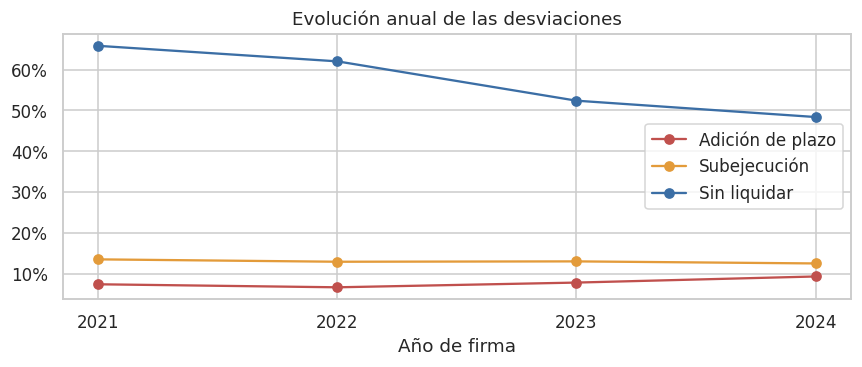

,adicion,subejecucion,sin_liquidar
anio,,,
2021,0.074,0.135,0.658
2022,0.067,0.129,0.620
2023,0.078,0.130,0.524
2024,0.093,0.125,0.484


In [24]:
serie = d.groupby("anio")[["adicion", "subejecucion", "sin_liquidar"]].mean()
ax = serie.rename(columns={"adicion": "Adición de plazo", "subejecucion": "Subejecución", "sin_liquidar": "Sin liquidar"}).plot(marker="o", figsize=(8, 3.5), color=["#c0504d", "#e39b3a", "#3b6ea5"], title="Evolución anual de las desviaciones")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.set_xticks(serie.index)
ax.set_xlabel("Año de firma")
plt.tight_layout()
plt.show()
serie

La adición de plazo sube un poco en 2024 (9,3 %) y la subejecución es estable alrededor del 13 %. La caída en contratos sin liquidar de 2021 a 2024 (66 % → 48 %) puede reflejar mejor registro o, simplemente, que los contratos más recientes todavía están dentro del plazo legal para liquidarse; por eso no la interpretamos como mejora.

### 3.3 Pruebas de hipótesis

Formulamos las hipótesis antes de correr las pruebas. En todas usamos α = 0,05 con corrección de Holm por el número de pruebas, y acompañamos cada resultado con su tamaño del efecto, porque con muestras tan grandes una diferencia puede ser "significativa" y a la vez irrelevante para decidir.

Convención para interpretar efectos: V de Cramér y h de Cohen ≈ 0,1 pequeño, 0,3 mediano, 0,5 grande; biserial de rangos ≈ 0,1 pequeño, 0,3 mediano, 0,5 grande.

In [25]:
resultados = []


def cramers_v(tabla):
    chi2 = stats.chi2_contingency(tabla)[0]
    n = tabla.values.sum()
    return np.sqrt(chi2 / (n * (min(tabla.shape) - 1)))


def prueba_chi2(h, var, grupo, data=d):
    x = data[[var, grupo]].dropna()
    tabla = pd.crosstab(x[grupo], x[var])
    chi2, p, gl, _ = stats.chi2_contingency(tabla)
    resultados.append({"hipótesis": h, "prueba": f"Chi² (gl={gl})", "estadístico": chi2, "p": p, "efecto": cramers_v(tabla), "métrica efecto": "V de Cramér", "n": len(x)})


def prueba_proporciones(h, var, grupo, a, b, data=d):
    x = data[[var, grupo]].dropna()
    ga, gb = x.loc[x[grupo] == a, var], x.loc[x[grupo] == b, var]
    z, p = proportions_ztest([ga.sum(), gb.sum()], [len(ga), len(gb)])
    h_cohen = 2 * np.arcsin(np.sqrt(ga.mean())) - 2 * np.arcsin(np.sqrt(gb.mean()))
    resultados.append({"hipótesis": h, "prueba": f"z dos proporciones ({ga.mean():.1%} vs {gb.mean():.1%})", "estadístico": z, "p": p, "efecto": h_cohen, "métrica efecto": "h de Cohen", "n": len(ga) + len(gb)})


def prueba_mw(h, valor, var, data=d):
    x = data[[valor, var]].dropna()
    a, b = x.loc[x[var] == 1, valor], x.loc[x[var] == 0, valor]
    u, p = stats.mannwhitneyu(a, b, alternative="two-sided")
    r = 2 * u / (len(a) * len(b)) - 1
    resultados.append({"hipótesis": h, "prueba": f"Mann-Whitney (mediana {10**a.median()/1e6:,.0f}M vs {10**b.median()/1e6:,.0f}M)", "estadístico": u, "p": p, "efecto": r, "métrica efecto": "biserial de rangos", "n": len(x)})


def prueba_spearman(h, x_col, y_col, data=d):
    x = data[[x_col, y_col]].dropna()
    rho, p = stats.spearmanr(x[x_col], x[y_col])
    resultados.append({"hipótesis": h, "prueba": "Spearman", "estadístico": rho, "p": p, "efecto": rho, "métrica efecto": "rho", "n": len(x)})

**Hipótesis planteadas** (H0 en cada caso: no hay asociación / no hay diferencia):

- **H1.** Los contratos con adición de plazo tienen un valor mayor que los que no la tienen.
- **H2.** La tasa de adición de plazo depende de la modalidad de contratación.
- **H3.** Los contratos de inversión tienen más adiciones de plazo que los de funcionamiento.
- **H4.** Los contratos de suministro tienen más subejecución que los de compraventa (por la figura de "monto agotable").
- **H5.** La tasa de desviación difiere entre sectores.
- **H6.** Las entidades territoriales dejan más contratos sin liquidar que las nacionales.
- **H7.** A mayor duración pactada, mayor probabilidad de adición de plazo.
- **H8.** Los contratos adjudicados a pymes tienen una tasa de desviación distinta que los adjudicados a no pymes.
- **H9.** Habilitar pago adelantado cambia la probabilidad de subejecución.
- **H10.** Los contratos adjudicados a consorcios o uniones temporales (`es_grupo`) tienen una tasa de adición de plazo distinta.
- **H11.** La tasa de adición de plazo ha cambiado entre 2021 y 2024.
- **H12.** La tasa de subejecución ha cambiado entre 2021 y 2024.
- **H13.** La tasa de desviación difiere según el género del representante legal del proveedor.

In [26]:
prueba_mw("H1 Valor: con vs sin adición", "log_valor", "adicion")
prueba_chi2("H2 Adición ~ modalidad", "adicion", "modalidad")
prueba_proporciones("H3 Adición: inversión vs funcionamiento", "adicion", "destino_gasto", "Inversión", "Funcionamiento")
prueba_proporciones("H4 Subejecución: suministros vs compraventa", "subejecucion", "tipo_de_contrato", "Suministros", "Compraventa")
prueba_chi2("H5 Desviación ~ sector", "desviacion", "sector", data=d[d.groupby("sector")["id_contrato"].transform("size") >= 200])
prueba_proporciones("H6 Sin liquidar: territorial vs nacional", "sin_liquidar", "orden", "Territorial", "Nacional")
prueba_spearman("H7 Duración pactada vs adición", "duracion_pactada", "adicion")
prueba_proporciones("H8 Desviación: pyme vs no pyme", "desviacion", "es_pyme", "Si", "No")
prueba_proporciones("H9 Subejecución: pago adelantado sí vs no", "subejecucion", "habilita_pago_adelantado", "Si", "No")
prueba_proporciones("H10 Adición: consorcio/UT vs individual", "adicion", "es_grupo", "Si", "No")
prueba_chi2("H11 Adición ~ año", "adicion", "anio")
prueba_chi2("H12 Subejecución ~ año", "subejecucion", "anio")
prueba_proporciones("H13 Desviación: representante mujer vs hombre", "desviacion", "g_nero_representante_legal", "Mujer", "Hombre")

tabla_h = pd.DataFrame(resultados)
tabla_h["p_holm"] = multipletests(tabla_h["p"], method="holm")[1]
tabla_h["decisión"] = np.where(tabla_h["p_holm"] < 0.05, "Se rechaza H0", "No se rechaza H0")
tabla_h["magnitud"] = pd.cut(tabla_h["efecto"].abs(), [0, .1, .3, .5, 10], labels=["despreciable", "pequeño", "mediano", "grande"], right=False)
tabla_h.style.format({"estadístico": "{:,.2f}", "p": "{:.2e}", "p_holm": "{:.2e}", "efecto": "{:.3f}", "n": "{:,}"}).hide(axis="index")

hipótesis,prueba,estadístico,p,efecto,métrica efecto,n,p_holm,decisión,magnitud
H1 Valor: con vs sin adición,Mann-Whitney (mediana 90M vs 34M),"698,035,063.50",0.00e+00,0.340,biserial de rangos,"119,505",0.00e+00,Se rechaza H0,mediano
H2 Adición ~ modalidad,Chi² (gl=5),"1,745.52",0.00e+00,0.121,V de Cramér,"119,505",0.00e+00,Se rechaza H0,pequeño
H3 Adición: inversión vs funcionamiento,z dos proporciones (9.4% vs 6.9%),16.03,8.13e-58,0.093,h de Cohen,"119,376",4.88e-57,Se rechaza H0,despreciable
H4 Subejecución: suministros vs compraventa,z dos proporciones (17.5% vs 7.5%),30.18,3.93e-200,0.307,h de Cohen,"41,737",3.93e-199,Se rechaza H0,mediano
H5 Desviación ~ sector,Chi² (gl=22),799.00,9.25e-155,0.082,V de Cramér,"119,243",7.40e-154,Se rechaza H0,despreciable
H6 Sin liquidar: territorial vs nacional,z dos proporciones (62.4% vs 50.8%),30.03,4.39e-198,0.235,h de Cohen,"65,345",3.96e-197,Se rechaza H0,pequeño
H7 Duración pactada vs adición,Spearman,0.09,1.33e-226,0.093,rho,"119,360",1.46e-225,Se rechaza H0,despreciable
H8 Desviación: pyme vs no pyme,z dos proporciones (12.2% vs 13.5%),-5.79,7.22e-09,-0.042,h de Cohen,"119,505",2.89e-08,Se rechaza H0,despreciable
H9 Subejecución: pago adelantado sí vs no,z dos proporciones (31.4% vs 12.9%),3.92,8.68e-05,0.454,h de Cohen,"41,442",2.60e-04,Se rechaza H0,mediano
H10 Adición: consorcio/UT vs individual,z dos proporciones (17.3% vs 7.7%),17.32,3.28e-67,0.294,h de Cohen,"119,505",2.29e-66,Se rechaza H0,pequeño


In [27]:
x = d[d["habilita_pago_adelantado"].isin(["Si", "No"])]
print(pd.crosstab(x["habilita_pago_adelantado"], x["subejecucion"], margins=True))

subejecucion              0.000  1.000    All
habilita_pago_adelantado                     
No                        36045   5346  41391
Si                           35     16     51
All                       36080   5362  41442


**Lectura de las pruebas:**

- **H1 (valor):** se rechaza H0 y es el efecto más fuerte de todo el análisis (biserial ≈ 0,34, mediano). Los contratos con adición tienen un valor mediano de ~$90 millones contra ~$34 millones de los que no la tienen.
- **H2 (modalidad):** se rechaza H0, pero el efecto es pequeño (V ≈ 0,12). Como vimos, parte de esa asociación se explica por el valor (se revisa en 3.4).
- **H3 (inversión vs funcionamiento):** significativa, pero con un efecto despreciable (h ≈ 0,09). Estadísticamente hay diferencia; en la práctica no sirve por sí sola para focalizar.
- **H4 (suministros):** se rechaza H0 con un efecto mediano (h ≈ 0,31). Los suministros duplican la tasa de subejecución.
- **H5 (sector):** significativa, pero con V ≈ 0,08. El sector aporta poco de forma aislada; solo unos pocos sectores se salen del promedio.
- **H6 (territorial y liquidación):** efecto pequeño pero relevante (h ≈ 0,24): las territoriales dejan sin liquidar 12 puntos porcentuales más.
- **H7 (duración):** correlación positiva pero débil (ρ ≈ 0,09) porque la relación no es lineal: sube hasta los 90 días, baja un poco entre 3 y 12 meses y se dispara en los contratos de más de un año.
- **H8 (pyme):** significativa por el tamaño de muestra, pero el efecto es despreciable (12,2 % vs 13,5 %).
- **H9 (pago adelantado):** la diferencia es grande (31 % vs 13 %) pero se apoya en **solo 51 contratos**, 16 con subejecución. La tomamos como una señal a vigilar, no como una conclusión.
- **H10 (consorcios/UT):** la adición es más del doble en consorcios (17 % vs 8 %). En 3.4 se ve que este efecto desaparece al controlar por valor: los consorcios se forman para contratos grandes.
- **H11 (adición por año):** significativa pero despreciable (V ≈ 0,04).
- **H12 (subejecución por año):** **no se rechaza H0** (p ajustado ≈ 0,32). La subejecución es estable entre 2021 y 2024 (12,5 %–13,5 %), lo que sugiere un patrón estructural y no algo coyuntural.
- **H13 (género del representante legal):** **no se rechaza H0** (p ajustado ≈ 0,32; 12,2 % vs 12,5 %). No hay evidencia de diferencias, así que no debe usarse como criterio.

La lección general es que con 120 mil contratos **la significancia estadística no es suficiente**; el tamaño del efecto es lo que separa los criterios útiles (valor, tipo de contrato, modalidad en ciertos casos) de los que no aportan (año, pyme, género, sector aislado).

### 3.4 Análisis multivariado: regresión logística

Varias características están relacionadas entre sí: la licitación pública se usa para contratos grandes, la inversión tiene valores más altos, etc. La regresión logística permite ver el efecto de cada atributo **manteniendo los demás constantes**. Reportamos *odds ratios* (OR > 1 aumenta la probabilidad de desviación). La categoría de referencia es un contrato de mínima cuantía, de funcionamiento, del orden nacional, de compraventa y no pyme.

In [28]:
FORMULA = (
    "{y} ~ log_valor + np.log1p(duracion_pactada) + C(modalidad, Treatment('Mínima cuantía'))"
    " + C(destino_gasto) + C(orden) + C(tipo_de_contrato) + C(es_pyme) + C(es_grupo)"
)
base_modelo = d[
    d["destino_gasto"].isin(["Funcionamiento", "Inversión"])
    & d["orden"].isin(["Nacional", "Territorial"])
    & d["duracion_pactada"].notna()
].copy()
base_modelo["modalidad"] = base_modelo["modalidad"].astype(str)


def ajustar(y, data):
    return smf.logit(FORMULA.format(y=y), data=data.dropna(subset=[y])).fit(disp=0)


def tabla_or(m):
    ci = np.exp(m.conf_int())
    t = pd.DataFrame({"OR": np.exp(m.params), "IC95_inf": ci[0], "IC95_sup": ci[1], "p": m.pvalues})
    t.index = (t.index.str.replace(r"C\(modalidad, Treatment\('Mínima cuantía'\)\)\[T\.", "Modalidad: ", regex=True)
               .str.replace(r"C\((\w+)\)\[T\.", r"\1: ", regex=True).str.replace("]", ""))
    return t.drop("Intercept")


modelos = {y: ajustar(y, base_modelo) for y in ["adicion", "subejecucion", "sin_liquidar"]}
for y, m in modelos.items():
    print(f"{y:<14} n={int(m.nobs):>7,}   pseudo-R² McFadden={m.prsquared:.3f}")

or_tabla = pd.concat({y: tabla_or(m)[["OR", "p"]] for y, m in modelos.items()}, axis=1)
or_tabla.style.format("{:.3f}").background_gradient(subset=[(y, "OR") for y in modelos], cmap="RdBu_r", vmin=0, vmax=2)

adicion        n=117,826   pseudo-R² McFadden=0.066
subejecucion   n= 41,081   pseudo-R² McFadden=0.054
sin_liquidar   n= 65,152   pseudo-R² McFadden=0.041


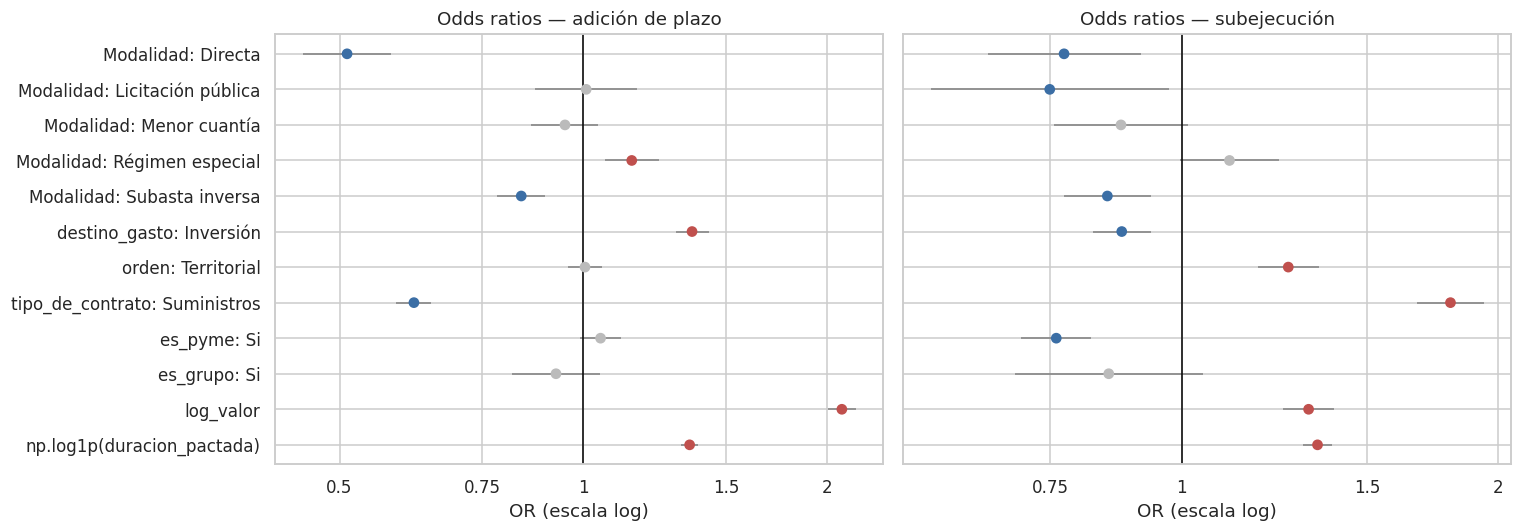

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, y in zip(axes, ["adicion", "subejecucion"]):
    t = tabla_or(modelos[y])
    colores = np.where(t["p"] < 0.05, np.where(t["OR"] > 1, "#c0504d", "#3b6ea5"), "#bbbbbb")
    ax.errorbar(t["OR"], range(len(t)), xerr=[t["OR"] - t["IC95_inf"], t["IC95_sup"] - t["OR"]], fmt="none", ecolor="gray", lw=1)
    ax.scatter(t["OR"], range(len(t)), c=colores, zorder=3)
    ax.axvline(1, color="black", lw=1)
    ax.set_xscale("log")
    ax.xaxis.set_major_locator(mtick.FixedLocator([.5, .75, 1, 1.5, 2]))
    ax.xaxis.set_major_formatter(mtick.FormatStrFormatter("%.2g"))
    ax.xaxis.set_minor_locator(mtick.NullLocator())
    ax.set_yticks(range(len(t)))
    ax.set_yticklabels(t.index)
    ax.set(title={"adicion": "Odds ratios — adición de plazo", "subejecucion": "Odds ratios — subejecución"}[y], xlabel="OR (escala log)")
axes[0].invert_yaxis()
plt.tight_layout()
plt.show()

Hipótesis adicionales que se contrastan con el modelo (controlando por las demás variables):

- **H14.** Controlando por valor y duración, la licitación pública tiene más adiciones de plazo que la mínima cuantía. → **No se rechaza H0** (OR ≈ 1,01; p ≈ 0,92). El 25 % de adición en licitaciones se explica por el tamaño y la duración de esos contratos, no por la modalidad en sí. Lo mismo ocurre con menor cuantía (p ≈ 0,28).
- **H15.** Controlando por el resto, los consorcios/UT tienen más adiciones. → **No se rechaza H0** (OR ≈ 0,93; p ≈ 0,22). El efecto bruto de H10 era confusión con el valor.
- **H16.** Controlando por el resto, las entidades territoriales tienen más adiciones que las nacionales. → **No se rechaza H0** (OR ≈ 1,00; p ≈ 0,86). Sí tienen más subejecución (OR ≈ 1,26) y más contratos sin liquidar (OR ≈ 1,29).

Lo que **sí** se mantiene con controles:

- **Valor:** cada vez que el valor se multiplica por 10, las probabilidades (odds) de adición se duplican (OR ≈ 2,1) y las de subejecución suben un 32 %.
- **Duración pactada** (OR ≈ 1,35 por unidad de log): mayor riesgo tanto de adición como de subejecución.
- **Suministros:** menos adición (OR ≈ 0,62) pero **80 % más odds de subejecución** (OR ≈ 1,8).
- **Inversión:** más adición (OR ≈ 1,36) y más contratos sin liquidar (OR ≈ 1,52).
- **Régimen especial:** 2,6 veces más odds de quedar sin liquidar. Es la señal más fuerte en esa dimensión.
- **Contratación directa:** la mitad de odds de adición (OR ≈ 0,51).

Los pseudo-R² son bajos (0,04–0,07), lo cual es normal en eventos poco frecuentes con variables administrativas: las características de la firma **ordenan el riesgo**, pero no predicen caso a caso.

### 3.5 ¿Cuánto se gana focalizando? Validación temporal

Para que los criterios sirvan "desde el momento de la firma", el modelo solo usa variables conocidas en ese momento. Lo entrenamos con contratos firmados entre 2021 y 2023 y lo evaluamos en 2024, simulando que la oficina aplica la regla a contratos nuevos. La variable objetivo es la desviación combinada (adición o subejecución).

In [30]:
entreno = base_modelo[base_modelo["anio"] <= 2023].dropna(subset=["desviacion"])
prueba = base_modelo[base_modelo["anio"] == 2024].dropna(subset=["desviacion"]).copy()
m_desv = ajustar("desviacion", entreno)
prueba["riesgo"] = m_desv.predict(prueba)
auc = roc_auc_score(prueba["desviacion"], prueba["riesgo"])
print(f"Entrenamiento: {len(entreno):,} contratos | Prueba 2024: {len(prueba):,} contratos")
print(f"AUC en 2024: {auc:.3f}")

Entrenamiento: 83,746 contratos | Prueba 2024: 34,080 contratos
AUC en 2024: 0.668


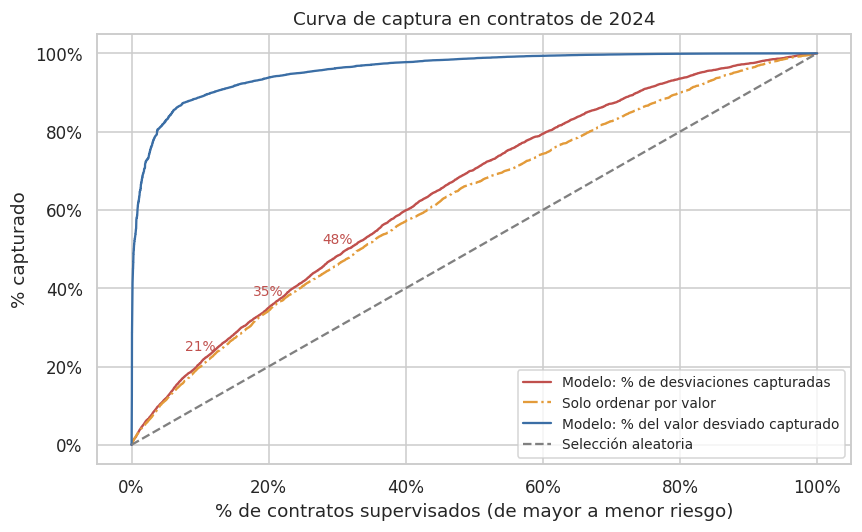

,% contratos revisados,% desviaciones (modelo),% desviaciones (solo valor),% valor desviado (modelo)
0,0.100,0.209,0.199,0.889
1,0.200,0.350,0.343,0.938
2,0.300,0.483,0.459,0.963
3,0.500,0.703,0.668,0.987


In [31]:
orden_riesgo = prueba.sort_values("riesgo", ascending=False)
frac = np.arange(1, len(orden_riesgo) + 1) / len(orden_riesgo)
captura = orden_riesgo["desviacion"].cumsum() / orden_riesgo["desviacion"].sum()
captura_valor = (orden_riesgo["valor_real"] * orden_riesgo["desviacion"]).cumsum() / (orden_riesgo["valor_real"] * orden_riesgo["desviacion"]).sum()

por_valor = prueba.sort_values("valor_real", ascending=False)
captura_solo_valor = por_valor["desviacion"].cumsum() / por_valor["desviacion"].sum()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(frac, captura, label="Modelo: % de desviaciones capturadas", color="#c0504d")
ax.plot(frac, captura_solo_valor.values, label="Solo ordenar por valor", color="#e39b3a", ls="-.")
ax.plot(frac, captura_valor, label="Modelo: % del valor desviado capturado", color="#3b6ea5")
ax.plot([0, 1], [0, 1], ls="--", color="gray", label="Selección aleatoria")
for f in [.1, .2, .3]:
    i = int(f * len(frac)) - 1
    ax.annotate(f"{captura.iloc[i]:.0%}", (f, captura.iloc[i]), textcoords="offset points", xytext=(-10, 8), fontsize=9, color="#c0504d")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.set(title="Curva de captura en contratos de 2024", xlabel="% de contratos supervisados (de mayor a menor riesgo)", ylabel="% capturado")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

pd.DataFrame({
    "% contratos revisados": [.1, .2, .3, .5],
    "% desviaciones (modelo)": [captura.iloc[int(f * len(frac)) - 1] for f in [.1, .2, .3, .5]],
    "% desviaciones (solo valor)": [captura_solo_valor.iloc[int(f * len(frac)) - 1] for f in [.1, .2, .3, .5]],
    "% valor desviado (modelo)": [captura_valor.iloc[int(f * len(frac)) - 1] for f in [.1, .2, .3, .5]],
})

Con un AUC de **0,67** en 2024 (datos que el modelo no vio), la capacidad de discriminación es moderada. Aun así, supervisando el **20 %** de contratos con mayor riesgo se capturaría el **35 %** de las desviaciones y el **94 % del valor** de los contratos que se desviaron. Con el 30 % se llega casi a la mitad de los casos.

Un resultado importante: **ordenar solo por valor da casi lo mismo** que el modelo completo (34 % vs 35 % al revisar el 20 %). Para la oficina, esto significa que el valor es el criterio principal y que las demás variables sirven más para decidir *qué revisar* (plazo, ejecución o liquidación) que para decidir *a quién* revisar.

### 3.6 De los resultados a reglas simples

Un modelo es útil para ordenar, pero la oficina necesita criterios que se puedan explicar y aplicar sin correr código. Traducimos los hallazgos a reglas y medimos, sobre los contratos de 2024, cuántos contratos marcaría cada una y qué tanto de las desviaciones captura (*lift* = tasa del grupo marcado / tasa general).

In [32]:
p80 = d.loc[d["anio"] <= 2023, "valor_real"].quantile(.8)
sectores_altos = (d[d["anio"] <= 2023].groupby("sector")
                  .filter(lambda g: len(g) >= 200).groupby("sector")["desviacion"].mean())
sectores_altos = sectores_altos[sectores_altos > d.loc[d["anio"] <= 2023, "desviacion"].mean() * 1.25].index.tolist()
print(f"Umbral de valor alto (p80 2021–2023): ${p80 / 1e6:,.0f} millones COP 2024")
print("Sectores de alta desviación:", sectores_altos)

p24 = d[d["anio"] == 2024].copy()
reglas = {
    "R1 Valor ≥ p80": p24["valor_real"] >= p80,
    "R2 Duración pactada > 90 días": p24["duracion_pactada"] > 90,
    "R3 Licitación, subasta o menor cuantía": p24["modalidad"].isin(["Licitación pública", "Subasta inversa", "Menor cuantía"]),
    "R4 Inversión y valor ≥ mediana": (p24["destino_gasto"] == "Inversión") & (p24["valor_real"] >= d["valor_real"].median()),
    "R5 Sector de alta desviación": p24["sector"].isin(sectores_altos),
}
reglas["Combinada: R1 o (R2 y R3) o R5"] = reglas["R1 Valor ≥ p80"] | (reglas["R2 Duración pactada > 90 días"] & reglas["R3 Licitación, subasta o menor cuantía"]) | reglas["R5 Sector de alta desviación"]

tasa_general = p24["desviacion"].mean()
filas = []
for nombre, mask in reglas.items():
    sub = p24.loc[mask, "desviacion"]
    filas.append({
        "regla": nombre,
        "% contratos marcados": mask.mean(),
        "tasa desviación marcados": sub.mean(),
        "lift": sub.mean() / tasa_general,
        "% desviaciones capturadas": sub.sum() / p24["desviacion"].sum(),
        "% del valor total marcado": p24.loc[mask, "valor_real"].sum() / p24["valor_real"].sum(),
    })
tabla_reglas = pd.DataFrame(filas)
print(f"Tasa general de desviación 2024: {tasa_general:.1%}")
tabla_reglas.style.format({c: "{:.1%}" for c in tabla_reglas.columns if c.startswith("%") or c.startswith("tasa")} | {"lift": "{:.2f}"}).hide(axis="index")

Umbral de valor alto (p80 2021–2023): $159 millones COP 2024
Sectores de alta desviación: ['Planeación', 'Trabajo']
Tasa general de desviación 2024: 13.9%


regla,% contratos marcados,tasa desviación marcados,lift,% desviaciones capturadas,% del valor total marcado
R1 Valor ≥ p80,18.8%,24.3%,1.75,32.8%,89.6%
R2 Duración pactada > 90 días,37.6%,18.8%,1.35,50.8%,69.7%
"R3 Licitación, subasta o menor cuantía",21.0%,21.4%,1.53,32.2%,61.3%
R4 Inversión y valor ≥ mediana,22.6%,19.0%,1.37,30.8%,45.6%
R5 Sector de alta desviación,8.2%,20.8%,1.49,12.3%,3.2%
Combinada: R1 o (R2 y R3) o R5,28.8%,22.8%,1.64,47.1%,91.4%


Con reglas simples se obtiene un desempeño similar al del modelo. La **regla combinada** marca el 29 % de los contratos de 2024, esos contratos se desvían 1,64 veces más que el promedio (22,8 % vs 13,9 %), captura el 47 % de las desviaciones y cubre el **91 % del valor** contratado. La regla de valor por sí sola (19 % de los contratos) ya cubre el 90 % del valor. Los umbrales se calcularon con 2021–2023 y se probaron en 2024, así que no están sobreajustados a los datos de prueba.

### 3.7 Insights principales

1. **El tamaño del contrato es el principal factor de riesgo.** Es el efecto más fuerte y el más estable: controla buena parte de lo que parecen diferencias por modalidad, destino o tipo de proveedor. El 20 % de contratos más grandes concentra el 90 % del dinero y tiene 1,75 veces más desviaciones.
2. **La modalidad importa menos de lo que parece.** La licitación pública tiene 4 veces más adiciones que la mínima cuantía, pero a igual valor y duración la diferencia desaparece. Donde la modalidad sí aporta información propia es en el **régimen especial**, que concentra contratos sin liquidar y subejecución.
3. **Cada tipo de contrato falla de forma distinta.** Las compraventas tienden a retrasarse (adición de plazo); los suministros tienden a no ejecutar el presupuesto. Esto sugiere enfocar la supervisión según el tipo: seguimiento de cronograma para compraventas y seguimiento financiero para suministros.
4. **La duración pactada es una alerta temprana.** La desviación se triplica entre los contratos de 15 días o menos (5 %) y los de más de 90 días (~16 %), y los de más de un año llegan al 45 %.
5. **Muchas diferencias son estadísticamente significativas pero irrelevantes en la práctica:** año, pyme, género del representante, sector de forma aislada. No se recomiendan como criterios.
6. **Hay un problema de trazabilidad en sí mismo.** El 37 % de los contratos terminados no registra facturación en SECOP II y el 56 % figura sin liquidar. Antes que un problema de ejecución, esto limita la capacidad de supervisión y debería ser un frente de trabajo propio.

## 4. Resultados: recomendaciones para la oficina de control interno

El informe ejecutivo completo está en `informe_ejecutivo.md` en la raíz del repositorio. Aquí va el resumen.

**Criterios de focalización recomendados** (aplicables al momento de la firma, validados en contratos de 2024):

| Prioridad | Criterio | Qué supervisar | Evidencia |
|---|---|---|---|
| 1 | **Valor ≥ $159 millones** (pesos 2024, percentil 80) | Seguimiento integral | 19 % de los contratos, 90 % del valor; 24 % de desviación (lift 1,75). OR de adición ≈ 2,1 por cada ×10 en valor. |
| 2 | **Duración pactada > 90 días en licitación, subasta inversa o menor cuantía** | Cronograma, entregas y ejecución financiera | La desviación pasa de 5 % (≤ 15 días) a ~16 % (> 90 días); estas modalidades tienen tasas de adición de 13–25 %. |
| 3 | **Contratos de más de un año** (cualquier modalidad) | Integral | 45 % de desviación, el grupo de mayor riesgo. |
| 4 | **Suministros de monto agotable de valor alto** | Ejecución financiera (liberar saldos a tiempo) | Subejecución de 17,5 % vs 7,5 % en compraventa; OR ≈ 1,8 con controles. |
| 5 | **Régimen especial y entidades territoriales** | Liquidación y cierre | Régimen especial: 73 % sin liquidar (OR ≈ 2,6). Territoriales: +12 p.p. sin liquidar. |
| 6 | **Inversión** | Cronograma | Más adiciones (OR ≈ 1,36) y más contratos sin liquidar (OR ≈ 1,52). |
| 7 | **Sectores Trabajo y Planeación** | Integral | Tasa de desviación ≥ 1,25 veces el promedio en 2021–2023; Trabajo es el sector más alto en todo el periodo (18,6 %). |

Con los criterios 1, 2 y 7 combinados se supervisaría el **29 % de los contratos**, que captura el **47 % de las desviaciones** y el **91 % del valor contratado**.

**Criterios que no recomendamos** usar para focalizar: si el proveedor es pyme, si es consorcio (su efecto se explica por el valor), el género del representante legal, el año de firma, o el orden de la entidad para temas de plazo.

**Recomendación adicional:** exigir que los supervisores registren pagos y liquidaciones en SECOP II. Hoy más de un tercio de los contratos cerrados no tiene trazabilidad financiera en la plataforma, lo que limita cualquier análisis de control.

### Limitaciones

- **Subregistro de pagos:** la subejecución solo se puede medir en el 63 % de los contratos terminados que registran facturación. Si las entidades que no registran pagos se comportan distinto, la tasa real puede ser diferente.
- **Liquidación:** no todos los contratos están obligados a liquidarse (depende del tipo de contrato y del manual de cada entidad), y los más recientes pueden estar aún dentro del plazo legal. El indicador de "sin liquidar" probablemente sobrestima el incumplimiento.
- **Desviación combinada heterogénea:** para contratos en ejecución o sin facturación, la desviación solo refleja adición de plazo. Esto puede hacer que los contratos con buen registro financiero parezcan más riesgosos.
- **Adiciones en valor no observadas:** el dataset solo trae adiciones en días. Las adiciones en dinero, que son una fuente importante de sobrecostos, no se pueden analizar.
- **Asociación, no causalidad:** los resultados muestran qué contratos tienden a desviarse, no por qué. Un contrato grande no se desvía "por ser grande", sino probablemente por su complejidad, que el valor aproxima.
- **Poder predictivo moderado** (AUC 0,67): los criterios ordenan el riesgo, pero muchos contratos marcados no se desviarán y algunos no marcados sí. Complementar con información no disponible aquí (historial del proveedor, cumplimiento previo de la entidad) mejoraría la focalización.
- **Deflactación aproximada:** se usó la variación anual del IPC de diciembre a diciembre para llevar a pesos de 2024, sin ajustar por mes de firma.
- **Periodo:** los resultados describen 2021–2024; cambios normativos posteriores o en el uso de SECOP II pueden modificar los patrones.